<a href="https://colab.research.google.com/github/4Delgo4/24-25-Nba-Stats-Data-Cleaning/blob/main/Homeless_shelter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10,6)
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
df = pd.read_csv('homelessness_shelter_data.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1000 non-null   int64  
 1   date               1000 non-null   object 
 2   shelter_name       1000 non-null   object 
 3   city               1000 non-null   object 
 4   state              1000 non-null   object 
 5   total_capacity     1000 non-null   int64  
 6   occupied_beds      1000 non-null   int64  
 7   available_beds     1000 non-null   int64  
 8   occupancy_rate     1000 non-null   float64
 9   average_age        1000 non-null   int64  
 10  male_percentage    1000 non-null   int64  
 11  female_percentage  1000 non-null   int64  
 12  season             1000 non-null   object 
 13  notes              913 non-null    object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


,id,total_capacity,occupied_beds,available_beds,occupancy_rate,average_age,male_percentage,female_percentage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,179.123000,91.874000,87.249000,51.214700,42.037000,54.634000,45.366000
std,288.819436,73.419195,67.068937,65.531224,28.880331,13.768122,8.797468,8.797468
min,1.000000,50.000000,0.000000,0.000000,0.000000,18.000000,40.000000,30.000000
25%,250.750000,115.000000,38.000000,35.000000,26.775000,30.000000,47.000000,38.000000
50%,500.500000,182.000000,76.000000,71.000000,51.850000,42.000000,55.000000,45.000000
75%,750.250000,243.000000,136.000000,128.250000,76.800000,54.000000,62.000000,53.000000
max,1000.000000,300.000000,294.000000,296.000000,100.000000,65.000000,70.000000,60.000000


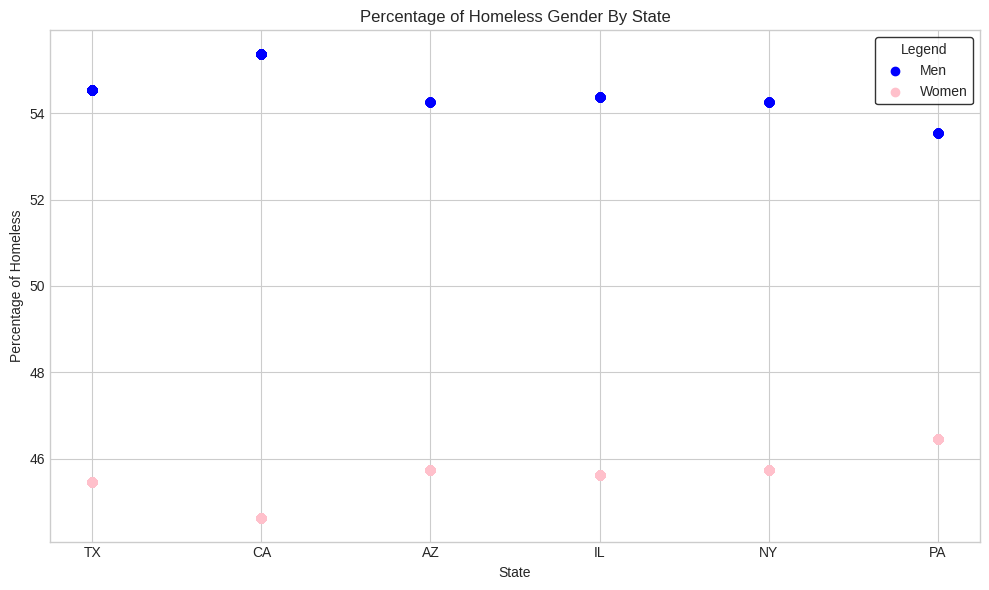

In [ ]:
#Homeless gender By States in Scatter Plot

plot1 = plt.scatter(df['state'], df.groupby("state")['male_percentage'].transform('mean'), color = 'blue')
plot2 = plt.scatter(df['state'], df.groupby("state")['female_percentage'].transform('mean'), color = 'pink')
plt.title("Percentage of Homeless Gender By State")
plt.xlabel("State")
plt.ylabel("Percentage of Homeless")
plt.tight_layout()
plt.legend(
    handles=[plot1, plot2],
    labels = ["Men", "Women"],
    loc='best',
    title = 'Legend',
    frameon=True,
    edgecolor='black')
plt.show()

In [ ]:
#The long way
def problem_per_centerlong():
    print("Number Of Each Problem Per Center")
    # Calculating sums
    stats = {
        'High Demand': (df['notes'] == "High Demand").sum(),
        'No issues reported': (df['notes'] == "No issues reported").sum(),
        'Staff shortage': (df['notes'] == "Staff shortage").sum(),
        'Excellent condition': (df['notes'] == "Excellent condition").sum(),
        'Needs maintenance': (df['notes'] == "Needs maintence").sum(),
        'Under inspection': (df['notes'] == "Under inspection").astype(int).sum(),
        'Overcrowded': (df['notes'] == "Overcrowded").sum(),
        'Recently renovated': (df['notes'] == "Recently renovated").sum()
    }
    return stats

# CALL THE FUNCTION OUTSIDE THE BLOCK
results = problem_per_centerlong()
print(results)

Number Of Each Problem Per Center
{'High Demand': np.int64(0), 'No issues reported': np.int64(107), 'Staff shortage': np.int64(112), 'Excellent condition': np.int64(105), 'Needs maintenance': np.int64(0), 'Under inspection': np.int64(107), 'Overcrowded': np.int64(130), 'Recently renovated': np.int64(119)}


In [ ]:
#Displaying Each Problem per center
print("Based on this table It seems like there is more problems then good in all the shelters, but A chunk of them are overcrowed")

rts = df.groupby('shelter_name')['notes'].value_counts()
print("Number Of Each Problem Per Center")
print(rts)

def problem_per_center():
    print("Total Problems In Centers combined")
    return df['notes'].value_counts()


print(problem_per_center())
print("Based on this table It seems like there is more problems then good in all the shelters, but A chunk of them are overcrowed, likely new shelters should be built")


Number Of Each Problem Per Center
shelter_name     notes             
Harbor Home      Overcrowded           18
                 Needs maintenance     17
                 No issues reported    15
                 Staff shortage        15
                 High demand           12
                                       ..
Sunrise Shelter  Overcrowded           14
                 Under inspection      13
                 No issues reported    10
                 Recently renovated    10
                 High demand            8
Name: count, Length: 80, dtype: int64
Total Problems In Centers combined
notes
Overcrowded            130
Needs maintenance      120
Recently renovated     119
High demand            113
Staff shortage         112
No issues reported     107
Under inspection       107
Excellent condition    105
Name: count, dtype: int64


<Axes: xlabel='season'>

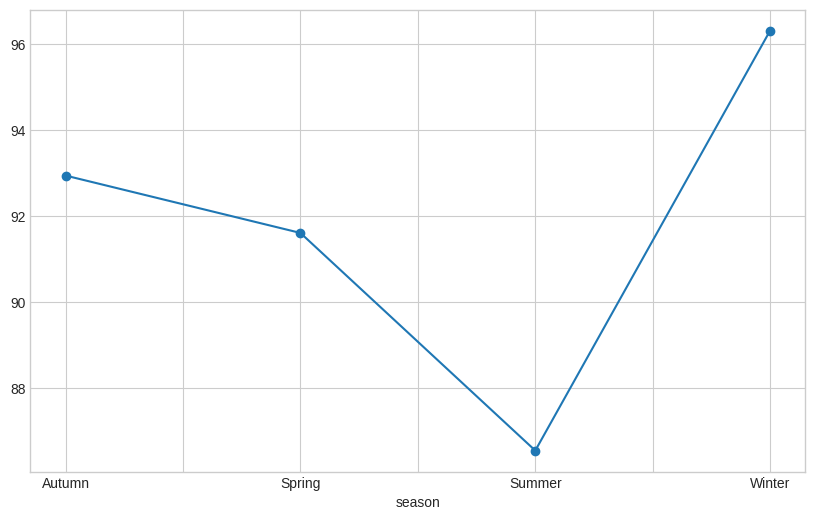

In [ ]:
#Homeless center Attendence based off season
df.groupby('season')['occupied_beds'].mean().plot(kind='line', marker = "o")
print("Based On the Data there is an slight decline in shelter attendence  in the summer then an increase in the Winter")